# **Analisis Sentimen Ulasan Game HayDay — Pelatihan Model**

In [115]:
# set seed agar hasil konsisten
import numpy as np
import random as python_random
import tensorflow as tf

np.random.seed(42)
python_random.seed(42)
tf.random.set_seed(42)

In [116]:
#instal Library
!pip install google-play-scraper Sastrawi

In [117]:
# import library
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [118]:
from google.colab import files
uploaded = files.upload()

Saving hayday_reviews.csv to hayday_reviews.csv


In [119]:
df = pd.read_csv('hayday_reviews.csv')
print(len(df), "data dimuat")
df.head()

10148 data dimuat


,userName,score,at,content
0,Pengguna Google,5,2026-09-24 23:21:18,game masa kecilku ini perkembangannya semakin ...
1,Pengguna Google,5,2026-09-24 19:05:11,Baguss gamenya
2,Pengguna Google,5,2026-09-24 18:54:11,game nya seruuu .. betah banget mainnyaa .. 🥰🥰
3,Pengguna Google,5,2026-09-24 18:15:30,game yang mencerminkan semua sifat manusia
4,Pengguna Google,5,2026-09-24 16:27:47,"gamenya cukup mudah untuk di mainkan, kemudian..."


# **Preprocessing Teks**

In [120]:
#cleaning
def cleaning(text):
    text = str(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['clean'] = df['content'].apply(cleaning)
df = df[df['clean'] != ''].reset_index(drop=True)

print(len(df), "data setelah cleaning")
df.head()

10060 data setelah cleaning


,userName,score,at,content,clean
0,Pengguna Google,5,2026-09-24 23:21:18,game masa kecilku ini perkembangannya semakin ...,game masa kecilku ini perkembangannya semakin ...
1,Pengguna Google,5,2026-09-24 19:05:11,Baguss gamenya,baguss gamenya
2,Pengguna Google,5,2026-09-24 18:54:11,game nya seruuu .. betah banget mainnyaa .. 🥰🥰,game nya seruuu betah banget mainnyaa
3,Pengguna Google,5,2026-09-24 18:15:30,game yang mencerminkan semua sifat manusia,game yang mencerminkan semua sifat manusia
4,Pengguna Google,5,2026-09-24 16:27:47,"gamenya cukup mudah untuk di mainkan, kemudian...",gamenya cukup mudah untuk di mainkan kemudian ...


In [121]:
#Normalisasi Slang
slang = {
    'gak': 'tidak', 'ga': 'tidak', 'kaga': 'tidak',
    'udah': 'sudah', 'aja': 'saja', 'nih': 'ini', 'tuh': 'itu',
    'bgt': 'banget', 'bangettt': 'banget', 'lemot': 'lambat',
    'ngaco': 'rusak', 'kebuka': 'terbuka', 'login': 'masuk',
    'serru': 'seru', 'seruu': 'seru', 'bgtu': 'begitu',
    'kren': 'keren', 'kereeen': 'keren', 'mantap': 'bagus',
    'jerin': 'berat', 'beratt': 'berat', 'gapapa': 'tidak apa apa',
    'yt': 'youtube', 'apk': 'aplikasi', 'aplikasinya': 'aplikasi',
    'game': 'permainan', 'gamenya': 'permainan',
}

def normalisasi(text):
    kata = text.split()
    kata = [slang.get(k, k) for k in kata]
    return ' '.join(kata)

df['clean'] = df['clean'].apply(normalisasi)

print(len(df), "data setelah normalisasi")

10060 data setelah normalisasi


In [122]:
#stopword menggunakan sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopword = StopWordRemoverFactory().create_stop_word_remover()

df['clean'] = df['clean'].apply(stopword.remove)

print(len(df), "data setelah stopword")

10060 data setelah stopword


In [123]:
#stemming menngunakan sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

cache = {}

def stem_teks(text):
    kata = []
    for k in text.split():
        if k not in cache:
            cache[k] = stemmer.stem(k)
        kata.append(cache[k])
    return ' '.join(kata)

hasil = []
for i, t in enumerate(df['clean']):
    hasil.append(stem_teks(t))
    if (i+1) % 1000 == 0:
        print(f"{i+1} / {len(df)}")

df['clean'] = hasil

df = df[df['clean'] != ''].reset_index(drop=True)

print(len(df), "data setelah stemming")
df.head()

1000 / 10060
2000 / 10060
3000 / 10060
4000 / 10060
5000 / 10060
6000 / 10060
7000 / 10060
8000 / 10060
9000 / 10060
10000 / 10060
10051 data setelah stemming


,userName,score,at,content,clean
0,Pengguna Google,5,2026-09-24 23:21:18,game masa kecilku ini perkembangannya semakin ...,main masa kecil kembang makin asa
1,Pengguna Google,5,2026-09-24 19:05:11,Baguss gamenya,baguss main
2,Pengguna Google,5,2026-09-24 18:54:11,game nya seruuu .. betah banget mainnyaa .. 🥰🥰,main nya seruuu betah banget mainnyaa
3,Pengguna Google,5,2026-09-24 18:15:30,game yang mencerminkan semua sifat manusia,main cermin semua sifat manusia
4,Pengguna Google,5,2026-09-24 16:27:47,"gamenya cukup mudah untuk di mainkan, kemudian...",main cukup mudah di main kemudian ada hidup nyata


In [124]:
#banding antara teks asli dan hasil preprocessing
for i in range(5):
    print("ASLI :", df['content'].iloc[i])
    print("BERSIH:", df['clean'].iloc[i])
    print("---")

ASLI : game masa kecilku ini perkembangannya semakin terasa
BERSIH: main masa kecil kembang makin asa
---
ASLI : Baguss gamenya
BERSIH: baguss main
---
ASLI : game nya seruuu .. betah banget mainnyaa .. 🥰🥰
BERSIH: main nya seruuu betah banget mainnyaa
---
ASLI : game yang mencerminkan semua sifat manusia
BERSIH: main cermin semua sifat manusia
---
ASLI : gamenya cukup mudah untuk di mainkan, kemudian seperti berada dikehidupan nyata
BERSIH: main cukup mudah di main kemudian ada hidup nyata
---


In [125]:
# labeling 3 kelas pake kamus inset + bantuan rating
inset_pos = {
    'bagus': 2, 'suka': 2, 'seru': 2, 'keren': 3, 'senang': 2,
    'hebat': 3, 'baik': 1, 'mudah': 1, 'enak': 2, 'cepat': 1,
    'lancar': 2, 'menarik': 2, 'cinta': 3, 'juara': 2, 'aman': 1,
    'rekomendasi': 2, 'sukses': 2, 'lengkap': 1, 'top': 2, 'tarik': 2,
}
inset_neg = {
    'rusak': -3, 'jelek': -3, 'buruk': -3, 'gagal': -3,
    'error': -2, 'lambat': -1, 'parah': -3, 'susah': -1,
    'ribet': -2, 'berat': -1, 'kalah': -1, 'hang': -2,
    'crash': -2, 'sedih': -2, 'kecewa': -3, 'benci': -3,
    'tipu': -3, 'curang': -2, 'menyebalkan': -2, 'bodo': -2,
}

def labeling(row):
    skor = 0
    for k in row['clean'].split():
        skor += inset_pos.get(k, 0)
        skor += inset_neg.get(k, 0)

    # skor positif atau negatif langsung dipakai
    if skor >= 2:
        return 'positif'
    if skor <= -2:
        return 'negatif'

    # skor netral pakai rating bintang sebagai penentu
    if row['score'] == 3:
        return 'netral'
    if row['score'] >= 4:
        return 'positif'
    return 'negatif'

df['label'] = df.apply(labeling, axis=1)

df['label'].value_counts()

,count
label,
positif,6960
negatif,2478
netral,613


In [126]:
# contoh review tiap label
for lab in ['positif', 'netral', 'negatif']:
    print(f"=== {lab} ===")
    for t in df[df['label'] == lab]['clean'].head(3):
        print("-", t)
    print()

# simpan dataset final
df[['content', 'clean', 'label', 'score', 'at']].to_csv('hayday_labeled.csv', index=False)
print("disimpan: hayday_labeled.csv")

=== positif ===
- main masa kecil kembang makin asa
- baguss main
- main nya seruuu betah banget mainnyaa

=== netral ===
- ini akun cuma stuck diloading mohon cerah
- main simulasi baik maybe cuma minus bener bener sabar buat grinding
- entah main mulai asa sebal makin naik level mesin produksi makin mahal mesin produksi butuh bas jam siap produksi beberapa produk butuh beberapa jam siap guna itu sangat kebal

=== negatif ===
- hayday tolong kenapa jadi lama gin lambat kecewa lah sudah tahun tahun main main skrng malah kayak gin lemottt parah di baik hayday kasih bintang sudah baik saya kasih bintang full
- tiba nge bug parah ya mau loading langsung keluar gitu apa kena hack
- beli paket event sudah bayar paket sebut masuk akun main

disimpan: hayday_labeled.csv


# **SKEMA 1 - SVM + TF-IDF(2 Kelas, Split 80/20)**

In [127]:
# skema 1: svm + tf-idf, 2 kelas, split 80/20
df2 = df[df['label'].isin(['positif', 'negatif'])].reset_index(drop=True)

x = df2['clean']
y = df2['label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000)
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("data latih:", len(x_train))
print(pd.Series(y_train).value_counts())

data latih: 7550
label
positif    5568
negatif    1982
Name: count, dtype: int64


In [128]:
# skema 1: SVM+Evaluasi
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm = SVC(kernel='linear')
svm.fit(x_train_tfidf, y_train)

pred = svm.predict(x_test_tfidf)
akurasi1 = accuracy_score(y_test, pred)
print("akurasi skema 1 (svm + tf-idf, 2 kelas):", round(akurasi1 * 100, 2), "%")
print(classification_report(y_test, pred, zero_division=0))

akurasi skema 1 (svm + tf-idf, 2 kelas): 85.43 %
              precision    recall  f1-score   support

     negatif       0.74      0.70      0.72       496
     positif       0.89      0.91      0.90      1392

    accuracy                           0.85      1888
   macro avg       0.81      0.80      0.81      1888
weighted avg       0.85      0.85      0.85      1888



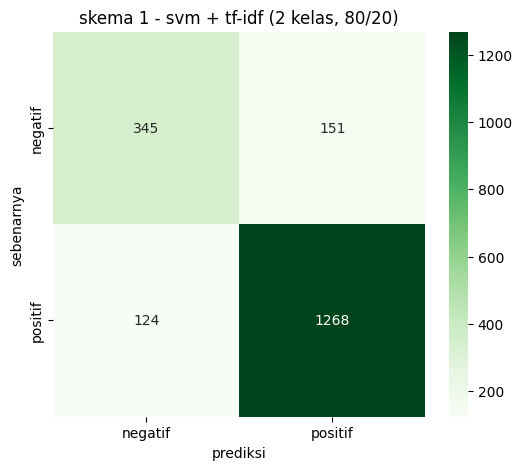

[{'skema': 1,
  'algoritma': 'SVM',
  'ekstraksi': 'TF-IDF',
  'split': '80/20',
  'akurasi_test': 85.43}]

In [129]:
# skema 1: CM + Catat
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel('prediksi')
plt.ylabel('sebenarnya')
plt.title('skema 1 - svm + tf-idf (2 kelas, 80/20)')
plt.show()

hasil_skema = [{
    'skema': 1,
    'algoritma': 'SVM',
    'ekstraksi': 'TF-IDF',
    'split': '80/20',
    'akurasi_test': round(akurasi1 * 100, 2)
}]

hasil_skema

# **Skema 2 — SVM + TF-IDF (2 Kelas, Split 70/30)**

In [130]:
# skema 2: svm + tf-idf, 2 kelas, split 70/30
x_train2, x_test2, y_train2, y_test2 = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

tfidf2 = TfidfVectorizer(max_features=5000)
x_train_t2 = tfidf2.fit_transform(x_train2)
x_test_t2 = tfidf2.transform(x_test2)

svm2 = SVC(kernel='linear')
svm2.fit(x_train_t2, y_train2)

pred2 = svm2.predict(x_test_t2)
akurasi2 = accuracy_score(y_test2, pred2)
print("akurasi skema 2 (svm + tf-idf, 2 kelas, 70/30):", round(akurasi2 * 100, 2), "%")
print(classification_report(y_test2, pred2, zero_division=0))

akurasi skema 2 (svm + tf-idf, 2 kelas, 70/30): 85.06 %
              precision    recall  f1-score   support

     negatif       0.73      0.68      0.71       744
     positif       0.89      0.91      0.90      2088

    accuracy                           0.85      2832
   macro avg       0.81      0.80      0.80      2832
weighted avg       0.85      0.85      0.85      2832



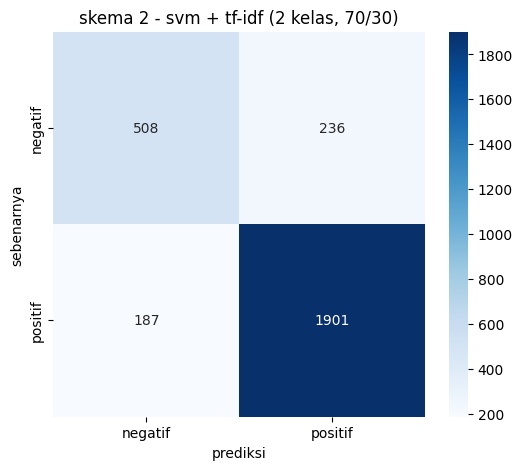

[{'skema': 1,
  'algoritma': 'SVM',
  'ekstraksi': 'TF-IDF',
  'split': '80/20',
  'akurasi_test': 85.43},
 {'skema': 2,
  'algoritma': 'SVM',
  'ekstraksi': 'TF-IDF',
  'split': '70/30',
  'akurasi_test': 85.06}]

In [131]:
# skema 2: CM + catat
cm2 = confusion_matrix(y_test2, pred2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm2.classes_, yticklabels=svm2.classes_)
plt.xlabel('prediksi')
plt.ylabel('sebenarnya')
plt.title('skema 2 - svm + tf-idf (2 kelas, 70/30)')
plt.show()

hasil_skema.append({
    'skema': 2,
    'algoritma': 'SVM',
    'ekstraksi': 'TF-IDF',
    'split': '70/30',
    'akurasi_test': round(akurasi2 * 100, 2)
})

hasil_skema

# **Skema 3 — LSTM Deep Learning (3 Kelas, Split 80/20)**

In [132]:
# oversampling
max_n = df['label'].value_counts().max()

bagian = []
for lab, grup in df.groupby('label'):
    kurang = max_n - len(grup)
    if kurang > 0:
        bagian.append(grup.sample(kurang, replace=True, random_state=42))
    bagian.append(grup)

df_bal = pd.concat(bagian).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_bal['label'].value_counts())
print("total:", len(df_bal))

label
negatif    6960
netral     6960
positif    6960
Name: count, dtype: int64
total: 20880


In [133]:
# skema 3: lstm, 3 kelas, split 80/20
x3 = df_bal['clean']
y3 = df_bal['label']

x_train3, x_test3, y_train3, y_test3 = train_test_split(
    x3, y3, test_size=0.2, random_state=42, stratify=y3
)

print("data latih:", len(x_train3), "| data tes:", len(x_test3))
print(y_test3.value_counts())


train_temp = pd.DataFrame({'clean': x_train3.values, 'label': y_train3.values})

max_n = train_temp['label'].value_counts().max()
bagian = []
for lab, grup in train_temp.groupby('label'):
    kurang = max_n - len(grup)
    if kurang > 0:
        bagian.append(grup.sample(kurang, replace=True, random_state=42))
    bagian.append(grup)

train_bal = pd.concat(bagian).sample(frac=1, random_state=42).reset_index(drop=True)

x_train3 = train_bal['clean']
y_train3 = train_bal['label']

print(y_train3.value_counts())

data latih: 16704 | data tes: 4176
label
netral     1392
positif    1392
negatif    1392
Name: count, dtype: int64
label
negatif    5568
netral     5568
positif    5568
Name: count, dtype: int64


In [134]:
# skema 3: Tokenizer + Pad + Label
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train3)

x_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(x_train3), maxlen=50, padding='post')
x_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(x_test3), maxlen=50, padding='post')

label_index = {'negatif': 0, 'netral': 1, 'positif': 2}
y_train_num = y_train3.map(label_index)
y_test_num = y_test3.map(label_index)

print("data latih:", len(x_train_pad), "| data tes:", len(x_test_pad))

data latih: 16704 | data tes: 4176


In [135]:
# arsitektur lstm
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

In [136]:
#skema 3: Latih
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

kelas_unik = np.unique(y_train_num)
bobot = compute_class_weight('balanced', classes=kelas_unik, y=y_train_num)
class_weight = dict(zip(kelas_unik, bobot))
print("class weight:", class_weight)

latih = model.fit(
    x_train_pad, y_train_num,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

class weight: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}
Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 23s 89ms/step - accuracy: 0.5495 - loss: 0.8927 - val_accuracy: 0.6040 - val_loss: 0.7462
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.7358 - loss: 0.6114 - val_accuracy: 0.8019 - val_loss: 0.5318
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.8661 - loss: 0.3670 - val_accuracy: 0.8411 - val_loss: 0.4278
Epoch 4/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.9157 - loss: 0.2456 - val_accuracy: 0.8560 - val_loss: 0.4097
Epoch 5/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9361 - loss: 0.1858 - val_accuracy: 0.8779 - val_loss: 0.3940


In [137]:
# skema 3: Evaluasi Train & Test
loss_train, acc_train = model.evaluate(x_train_pad, y_train_num, verbose=0)
loss_test, acc_test = model.evaluate(x_test_pad, y_test_num, verbose=0)

print(f"akurasi training : {round(acc_train * 100, 2)} %")
print(f"akurasi testing  : {round(acc_test * 100, 2)} %")

akurasi training : 93.49 %
akurasi testing  : 88.63 %


131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
              precision    recall  f1-score   support

     negatif       0.87      0.84      0.85      1392
      netral       0.87      0.97      0.92      1392
     positif       0.92      0.86      0.89      1392

    accuracy                           0.89      4176
   macro avg       0.89      0.89      0.89      4176
weighted avg       0.89      0.89      0.89      4176



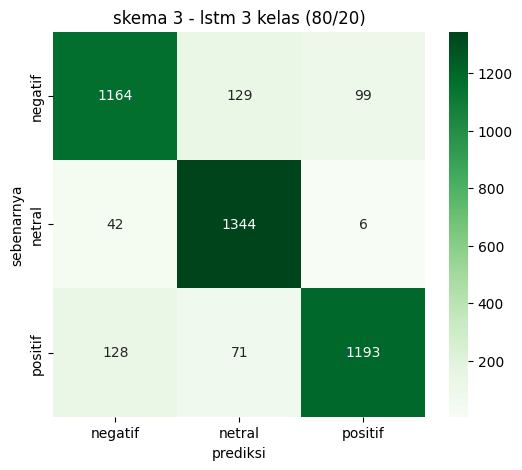

[{'skema': 1,
  'algoritma': 'SVM',
  'ekstraksi': 'TF-IDF',
  'split': '80/20',
  'akurasi_test': 85.43},
 {'skema': 2,
  'algoritma': 'SVM',
  'ekstraksi': 'TF-IDF',
  'split': '70/30',
  'akurasi_test': 85.06},
 {'skema': 3,
  'algoritma': 'LSTM (Deep Learning)',
  'ekstraksi': 'Tokenizer + Embedding',
  'split': '80/20',
  'kelas': '3 kelas',
  'akurasi_test': 88.63}]

In [138]:
# skema 3: Predict + CM + Catat
pred_prob = model.predict(x_test_pad)
pred_num = pred_prob.argmax(axis=1)

label_balik = {0: 'negatif', 1: 'netral', 2: 'positif'}
pred_label = [label_balik[p] for p in pred_num]
y_test_label = [label_balik[y] for y in y_test_num]

print(classification_report(y_test_label, pred_label, zero_division=0))

cm3 = confusion_matrix(y_test_label, pred_label,
                       labels=['negatif', 'netral', 'positif'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negatif', 'netral', 'positif'],
            yticklabels=['negatif', 'netral', 'positif'])
plt.xlabel('prediksi')
plt.ylabel('sebenarnya')
plt.title('skema 3 - lstm 3 kelas (80/20)')
plt.show()

hasil_skema.append({
    'skema': 3,
    'algoritma': 'LSTM (Deep Learning)',
    'ekstraksi': 'Tokenizer + Embedding',
    'split': '80/20',
    'kelas': '3 kelas',
    'akurasi_test': round(acc_test * 100, 2)
})

hasil_skema

# **Inference — Uji Model dengan Kalimat Baru**

In [139]:
# inference: uji model dengan kalimat baru
kalimat_baru = [
    "game ini seru banget, saya suka mainnya",
    "banyak bug, sering keluar sendiri, kecewa",
    "di update terbaru tersedia fitur pertanian dan ternak baru di permainan",
]

def preprocessing_inference(text):
    text = str(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    kata = text.split()
    kata = [slang.get(k, k) for k in kata]
    return stopword.remove(' '.join(kata))

for kalimat in kalimat_baru:
    teks_bersih = preprocessing_inference(kalimat)
    sekuens = tokenizer.texts_to_sequences([teks_bersih])
    pad = pad_sequences(sekuens, maxlen=50, padding='post')
    prob = model.predict(pad, verbose=0)
    kelas = prob.argmax(axis=1)[0]
    print(f"kalimat : {kalimat}")
    print(f"sentimen: {label_balik[kelas]}")
    print("---")

kalimat : game ini seru banget, saya suka mainnya
sentimen: positif
---
kalimat : banyak bug, sering keluar sendiri, kecewa
sentimen: negatif
---
kalimat : di update terbaru tersedia fitur pertanian dan ternak baru di permainan
sentimen: positif
---


In [140]:
pd.DataFrame(hasil_skema)

,skema,algoritma,ekstraksi,split,akurasi_test,kelas
0,1,SVM,TF-IDF,80/20,85.43,NaN
1,2,SVM,TF-IDF,70/30,85.06,NaN
2,3,LSTM (Deep Learning),Tokenizer + Embedding,80/20,88.63,3 kelas
